# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
# Data manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

# Install & import ucimlrepo (khusus untuk fetch dataset UCI)
!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
# Fetch dataset langsung dari UCI ML Repository
obesity = fetch_ucirepo(id=544)

X = obesity.data.features
y = obesity.data.targets

# Gabungkan jadi satu dataframe utuh
df = pd.concat([X, y], axis=1)

# Cek metadata dataset
print(obesity.metadata.name)
print(obesity.metadata.abstract)

# Simpan raw dataset ke folder obesity_raw (untuk struktur repo)
import os
os.makedirs('obesity_raw', exist_ok=True)
df.to_csv('obesity_raw/obesity_raw.csv', index=False)

# Cek struktur data
df.head()

Estimation of Obesity Levels Based On Eating Habits and Physical Condition 
This dataset include data for the estimation of obesity levels in individuals from the countries of Mexico, Peru and Colombia, based on their eating habits and physical condition. 


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah duplikat: 24
['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad']


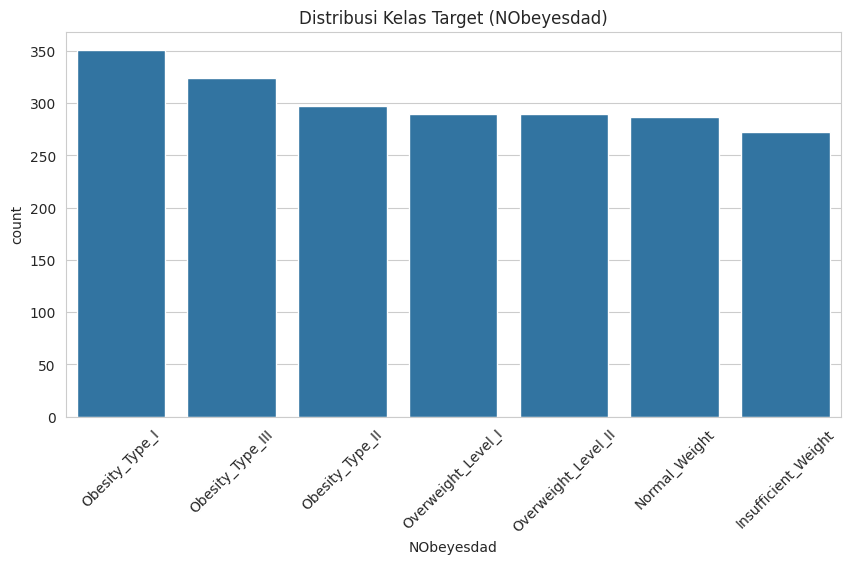

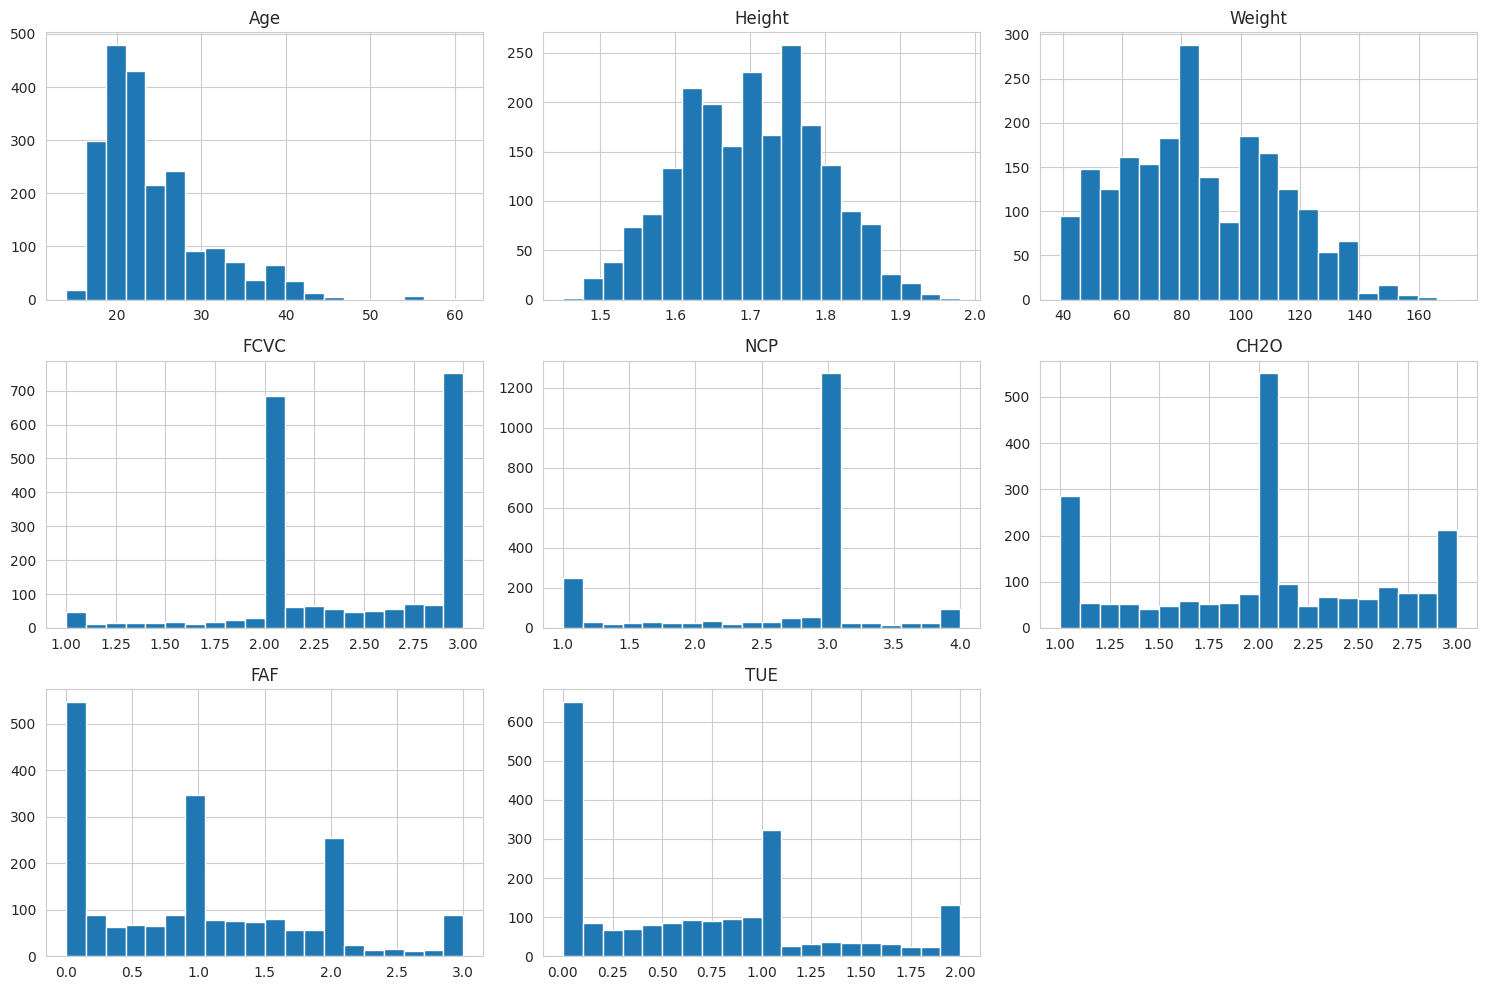

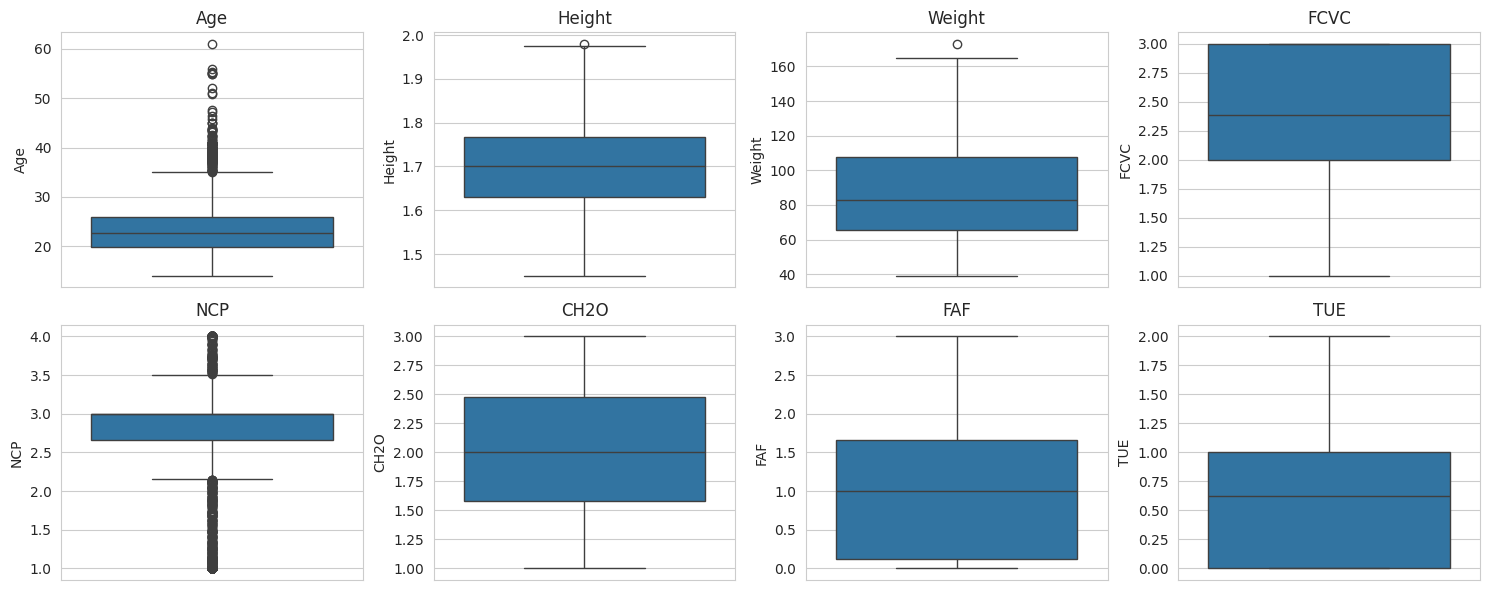

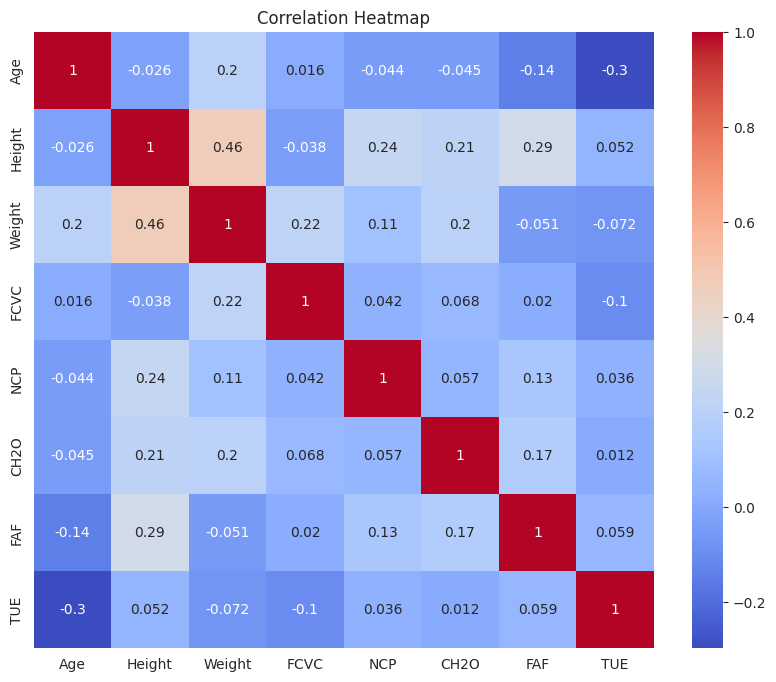

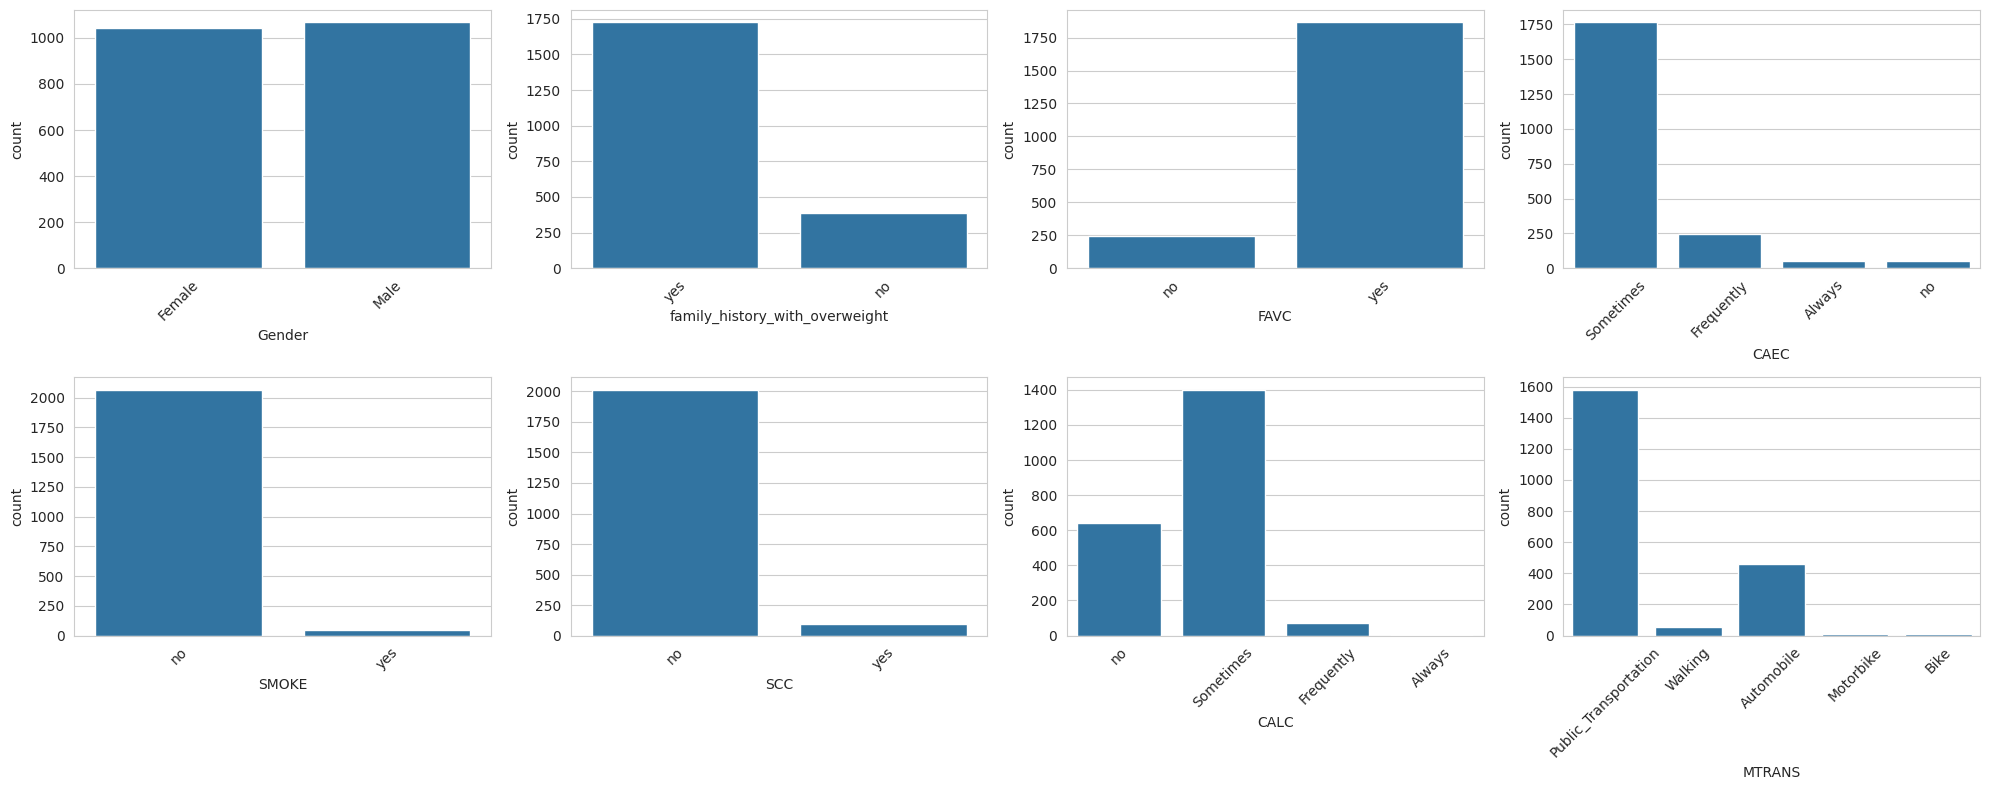

In [3]:
#Type your code here

# Statistik deskriptif
df.describe(include='all')

# Cek missing values
df.isnull().sum()

# Cek duplikat
print("Jumlah duplikat:", df.duplicated().sum())

# Cek nama kolom asli
print(df.columns.tolist())

# Distribusi target (NObeyesdad)
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribusi Kelas Target (NObeyesdad)")
plt.show()

# Distribusi fitur numerik
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
df[numerical_cols].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

# Cek outlier via boxplot
plt.figure(figsize=(15,6))
for i, col in enumerate(numerical_cols):
    plt.subplot(2,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Korelasi antar fitur numerik
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Distribusi fitur kategorikal
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
                     'SMOKE', 'SCC', 'CALC', 'MTRANS']
fig, axes = plt.subplots(2, 4, figsize=(20,8))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i//4, i%4])
    axes[i//4, i%4].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Cek & handle missing values (kalau ada)
print(df.isnull().sum().sum(), "missing values")
# kalau ada, bisa df.dropna() atau df.fillna()

# 2. Hapus duplikat
df = df.drop_duplicates()

# 3. Pisahkan fitur numerik & kategorikal
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
nominal_cols = ['CAEC', 'CALC', 'MTRANS']

# 4. Encoding fitur biner (Label Encoding, karena cuma 2 kategori)
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 5. Encoding fitur nominal (One-Hot Encoding, karena >2 kategori tanpa urutan)
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# 6. Encoding target
target_col = 'NObeyesdad'
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col])

# 7. Standarisasi fitur numerik
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 8. Split fitur & target
X_processed = df.drop(columns=[target_col])
y_processed = df[target_col]

# 9. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 10. Simpan hasil preprocessing ke folder preprocessing/obesity_preprocessing
os.makedirs('preprocessing/obesity_preprocessing', exist_ok=True)

X_train.to_csv('preprocessing/obesity_preprocessing/X_train.csv', index=False)
X_test.to_csv('preprocessing/obesity_preprocessing/X_test.csv', index=False)
y_train.to_csv('preprocessing/obesity_preprocessing/y_train.csv', index=False)
y_test.to_csv('preprocessing/obesity_preprocessing/y_test.csv', index=False)

0 missing values
Train shape: (1669, 23)
Test shape: (418, 23)
